<a href="https://colab.research.google.com/github/Rajeshsivamoorthy/ML_INTERPRETATION/blob/main/HEATMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
from google.colab import files
import os

uploaded = files.upload()

if not uploaded:
    print("No file was uploaded.")
else:
    for filename in uploaded.keys():
        print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

    # If multiple files are uploaded, let the user choose one
    if len(uploaded) > 1:
        print("Multiple files uploaded. Please select one to process:")
        for i, filename in enumerate(uploaded.keys()):
            print(f"{i+1}. {filename}")

        while True:
            try:
                choice = int(input("Enter the number corresponding to your chosen file: "))
                if 1 <= choice <= len(uploaded):
                    csv_file_name = list(uploaded.keys())[choice - 1]
                    print(f"Selected file: {csv_file_name}")
                    break
                else:
                    print("Invalid choice. Please enter a valid number.")
            except ValueError:
                print("Invalid input. Please enter a number.")
    else:
        csv_file_name = list(uploaded.keys())[0]

    # Now modify cell FJ2wSbwUxzZS to use this csv_file_name
    # This part would typically be handled by the agent modifying existing cells.
    # For now, we'll assign it to a global variable that the next cell can use.
    get_ipython().user_ns['csv_file_name_for_df'] = csv_file_name

print("Please execute the next cell to load the data into a DataFrame.")

Saving ML.csv to ML (1).csv
User uploaded file "ML (1).csv" with length 577 bytes
Please execute the next cell to load the data into a DataFrame.


In [33]:
import pandas as pd

# Use the filename from the upload cell, if available
csv_file_name = globals().get('csv_file_name_for_df', None)

if csv_file_name is None:
    # Fallback to prompt if file wasn't uploaded via the dedicated cell
    print("No file was uploaded or selected. Prompting for file name.")
    csv_file_name = input("Enter the name of your CSV file (e.g., 'my_data.csv'): ").strip()

# Read the CSV file into a DataFrame
try:
    df = pd.read_csv(csv_file_name)
    print(f"Successfully loaded '{csv_file_name}' into a DataFrame.")
    print("First 5 rows of the DataFrame:")
    display(df.head()) # Use display for better output in Colab
except FileNotFoundError:
    print(f"Error: The file '{csv_file_name}' was not found. Please ensure the file is uploaded to Colab or the path is correct.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors later
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors later

Successfully loaded 'ML (1).csv' into a DataFrame.
First 5 rows of the DataFrame:


,Model,ROC AUC,Accuracy,MCC,Precision,Recall,Specificty,F1-Score,PRC AUC
0,Random Tree,0.840,92.1865,0.620,0.917577,0.921865,0.654903,0.919057,0.907
1,Random Forest,0.945,93.3027,0.673,0.929404,0.933027,0.688085,0.930345,0.963
2,Decision Stump,0.683,87.3933,0.040,0.808363,0.873933,0.133593,0.818828,0.841
3,OneR,0.595,89.2318,0.354,0.879742,0.892318,0.298680,0.863597,0.816
4,Rep Tree,0.876,91.0703,0.547,0.902827,0.910703,0.567566,0.904760,0.923



Select metric scale:
1 → Values between 0 and 1
2 → Values between 0 and 100
Enter 1 or 2: 1

Enter output file type (png, tif, pdf): tif
Enter DPI value (300 / 600 / 900): 300


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

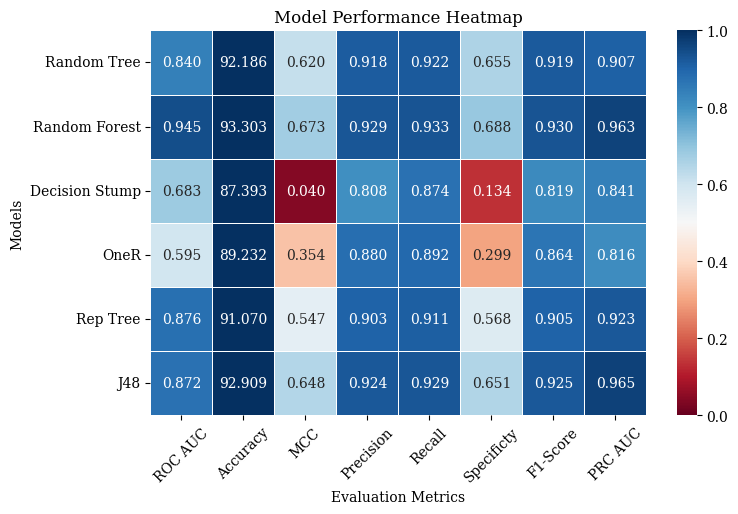

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Set font to Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plt.figure(figsize=(8,5))

# Set 'Model' column as index
if 'Model' in df.columns:
    df_plot = df.set_index('Model')
elif 'MODEL' in df.columns:
    df_plot = df.set_index('MODEL')
else:
    df_plot = df

# === Ask user for scale type ===
print("\nSelect metric scale:")
print("1 → Values between 0 and 1")
print("2 → Values between 0 and 100")

scale_choice = input("Enter 1 or 2: ").strip()

if scale_choice == "1":
    vmin_val = 0
    vmax_val = 1
elif scale_choice == "2":
    vmin_val = 0
    vmax_val = 100
else:
    print("Invalid choice. Defaulting to 0–1 scale.")
    vmin_val = 0
    vmax_val = 1

# === Plot heatmap ===
sns.heatmap(
    df_plot,
    annot=True,
    cmap="RdBu",
    linewidths=0.5,
    fmt=".3f",
    vmin=vmin_val,
    vmax=vmax_val
)

plt.title("Model Performance Heatmap")
plt.ylabel("Models")
plt.xlabel("Evaluation Metrics")
plt.xticks(rotation=45) # Rotate x-axis labels vertically

# === User input for output type and DPI ===
file_type = input("\nEnter output file type (png, tif, pdf): ").strip().lower()
dpi_value = int(input("Enter DPI value (300 / 600 / 900): ").strip())

# === Save figure ===
output_filename = f"HEATMAP.{file_type}"
plt.savefig(output_filename, dpi=dpi_value, bbox_inches='tight')

files.download(output_filename)

plt.show()